In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

# Import everything at once to keep it clean
from src.data_cleaning import (
    clean_lapd_data, 
    generate_quality_report, 
    save_processed_data, 
    export_quality_report
)
import pandas as pd

In [3]:
raw_data_path = os.path.join('..', 'data', 'Crime_Data_from_2020_to_Present.csv')

# Load the data
df_raw = pd.read_csv(raw_data_path)

quality_summary = generate_quality_report(df_raw)

print(f"Total Rows: {quality_summary['Total Records']}")
print(f"Date Range: {quality_summary['Date Range']}")

Total Rows: 1004991
Date Range: 01/01/2020 12:00:00 AM to 12/31/2023 12:00:00 AM


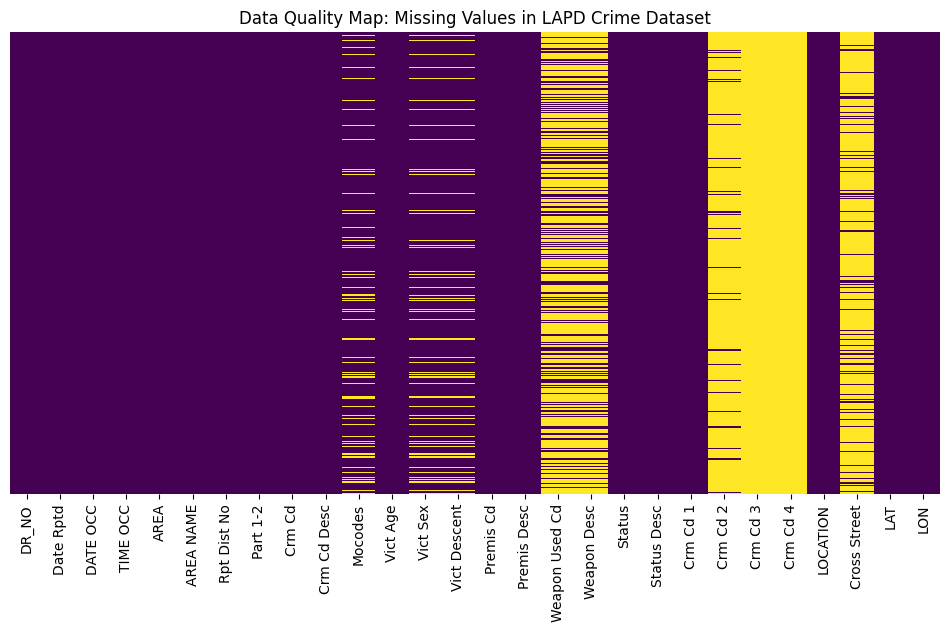

Critical Field Null Counts:
 LAT         0
LON         0
TIME OCC    0
DATE OCC    0
dtype: int64


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Data Quality Map: Missing Values in LAPD Crime Dataset')
plt.show()

null_summary = df_raw[['LAT', 'LON', 'TIME OCC', 'DATE OCC']].isnull().sum()
print("Critical Field Null Counts:\n", null_summary)

In [5]:
# Apply the modular cleaning logic
df_cleaned = clean_lapd_data(df_raw)

# Quality Verification
print(f"Original Records: {len(df_raw)}")
print(f"Records after Geospatial Filtering: {len(df_cleaned)}")
print(f"Data reduction: {((len(df_raw) - len(df_cleaned)) / len(df_raw)) * 100:.2f}%")

save_processed_data(df_cleaned, '../data/Crime_Data_from_2020_to_Present_Cleaned.csv')

c:\Users\aryam\Capstone-LAPDCrimeData\src\data_cleaning.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TIME OCC'] = df['TIME OCC'].astype(str).str.zfill(4)
c:\Users\aryam\Capstone-LAPDCrimeData\src\data_cleaning.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df['TIME OCC'].str[:2].astype(int)
c:\Users\aryam\Capstone-LAPDCrimeData\src\data_cleaning.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsin

Original Records: 1004991
Records after Geospatial Filtering: 1002751
Data reduction: 0.22%


In [6]:
report_path = os.path.join('..', 'reports', 'data_quality_report.json')
export_quality_report(df_cleaned, report_path)

Quality Report exported to: ..\reports\data_quality_report.json
